In [1]:
import pandas as pd
import numpy as np

# Load cleaned dataset
file_path = "../data/processed/cleaned_data.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (100000, 24)


In [2]:
# Calculate stock ratio
df["Stock_Ratio"] = df["Stock_On_Hand"] / df["Reorder_Level"]

# Create Inventory Health classes
def inventory_health(row):
    if row["Stock_Ratio"] < 3.27:
        return "Low Stock"
    elif row["Stock_Ratio"] <= 8.35:
        return "Healthy Stock"
    else:
        return "Overstocked"

df["Inventory_Health"] = df.apply(inventory_health, axis=1)

print("Inventory Health target created successfully!")
print("\nClass distribution:")
print(df["Inventory_Health"].value_counts())

Inventory Health target created successfully!

Class distribution:
Inventory_Health
Healthy Stock    50086
Overstocked      24964
Low Stock        24950
Name: count, dtype: int64


In [3]:
features = [
    "Units",
    "Selling_Price",
    "Revenue",
    "Margin",
    "Lead_Time_Days",
    "Customer_Age",
    "Loyalty_Flag",
    "Month",
    "Day_of_Week"
]

X = df[features]
y = df["Inventory_Health"]

print("Features selected successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features selected successfully!
X shape: (100000, 9)
y shape: (100000,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80000, 9)
Testing data: (20000, 9)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


TUNING KNN

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Create KNN model
knn = KNeighborsClassifier()

# Values of K to test
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15]
}

# Grid search
knn_grid = GridSearchCV(
    knn,
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

# Train and search for the best K
knn_grid.fit(X_train_scaled, y_train)

print("Best K:", knn_grid.best_params_)
print("Best CV F1 Score:", knn_grid.best_score_)

Best K: {'n_neighbors': 3}
Best CV F1 Score: 0.3858025970754458


In [7]:
# Get the best KNN model
tuned_knn = knn_grid.best_estimator_

# Make predictions on test data
tuned_knn_predictions = tuned_knn.predict(X_test_scaled)

print("Tuned KNN predictions generated successfully!")

Tuned KNN predictions generated successfully!


TUNING DECISION TREE

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Create Decision Tree model
decision_tree = DecisionTreeClassifier(random_state=42)

# Parameters to test
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, 20, None]
}

# Grid search
dt_grid = GridSearchCV(
    decision_tree,
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

# Train and search for the best parameters
dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best CV F1 Score:", dt_grid.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': None}
Best CV F1 Score: 0.37495505152716996


In [9]:
# Get the best Decision Tree model
tuned_decision_tree = dt_grid.best_estimator_

# Make predictions on test data
tuned_dt_predictions = tuned_decision_tree.predict(X_test)

print("Tuned Decision Tree predictions generated successfully!")

Tuned Decision Tree predictions generated successfully!


In [11]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

svm_model = LinearSVC(
    random_state=42,
    max_iter=5000
)

param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

svm_grid = GridSearchCV(
    svm_model,
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best CV F1 Score:", svm_grid.best_score_)

Best Parameters: {'C': 0.01}
Best CV F1 Score: 0.3342921073856125


In [12]:
tuned_svm = svm_grid.best_estimator_

tuned_svm_predictions = tuned_svm.predict(X_test_scaled)

print("Tuned SVM predictions generated successfully!")

Tuned SVM predictions generated successfully!


TUNING RANDOM FOREST

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

random_forest = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 10, 20]
}

rf_grid = GridSearchCV(
    random_forest,
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1 Score:", rf_grid.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 50}
Best CV F1 Score: 0.37627665207396016


In [14]:
tuned_random_forest = rf_grid.best_estimator_

tuned_rf_predictions = tuned_random_forest.predict(X_test)

print("Tuned Random Forest predictions generated successfully!")

Tuned Random Forest predictions generated successfully!


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tuned_results = []

models = {
    "KNN": tuned_knn_predictions,
    "Decision Tree": tuned_dt_predictions,
    "SVM": tuned_svm_predictions,
    "Random Forest": tuned_rf_predictions
}

for model_name, predictions in models.items():
    tuned_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, predictions, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, predictions, average="weighted", zero_division=0)
    })

tuned_results_df = pd.DataFrame(tuned_results)

print(tuned_results_df)

           Model  Accuracy  Precision   Recall  F1 Score
0            KNN   0.42515   0.379947  0.42515  0.389840
1  Decision Tree   0.37515   0.378249  0.37515  0.376640
2            SVM   0.50085   0.250851  0.50085  0.334278
3  Random Forest   0.46515   0.382152  0.46515  0.377797


In [16]:
import joblib

joblib.dump(tuned_knn, "../models/classification/tuned/knn.pkl")
joblib.dump(tuned_decision_tree, "../models/classification/tuned/decision_tree.pkl")
joblib.dump(tuned_svm, "../models/classification/tuned/svm.pkl")
joblib.dump(tuned_random_forest, "../models/classification/tuned/random_forest.pkl")
joblib.dump(scaler, "../models/classification/tuned/scaler.pkl")

print("All tuned classification models saved successfully!")

All tuned classification models saved successfully!


Random Forest Feature Importance

In [17]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": tuned_random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

          Feature  Importance
3          Margin    0.204371
2         Revenue    0.190413
1   Selling_Price    0.189642
5    Customer_Age    0.112697
4  Lead_Time_Days    0.088690
7           Month    0.085902
8     Day_of_Week    0.074320
0           Units    0.029275
6    Loyalty_Flag    0.024689


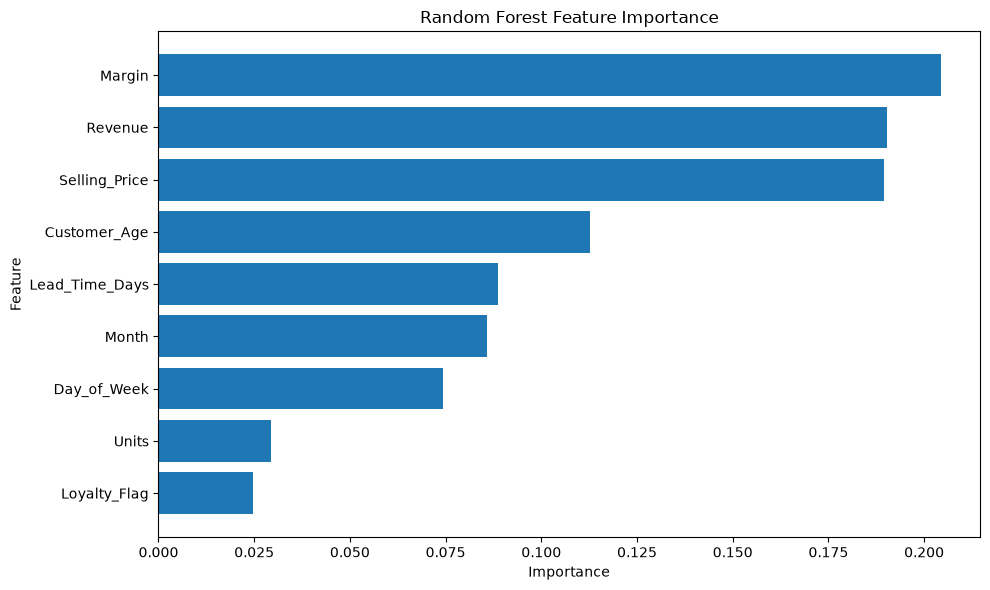

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [19]:
baseline_results = pd.DataFrame([
    {
        "Model": "KNN",
        "Accuracy": 0.45325,
        "Precision": 0.378152,
        "Recall": 0.45325,
        "F1 Score": 0.380207
    },
    {
        "Model": "Decision Tree",
        "Accuracy": 0.37515,
        "Precision": 0.378249,
        "Recall": 0.37515,
        "F1 Score": 0.376640
    },
    {
        "Model": "SVM",
        "Accuracy": 0.50085,
        "Precision": 0.250851,
        "Recall": 0.50085,
        "F1 Score": 0.334278
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.46960,
        "Precision": 0.376632,
        "Recall": 0.46960,
        "F1 Score": 0.370025
    }
])

baseline_results["Stage"] = "Baseline"
tuned_results_df["Stage"] = "Tuned"

comparison_df = pd.concat(
    [baseline_results, tuned_results_df],
    ignore_index=True
)

comparison_df = comparison_df[
    ["Model", "Stage", "Accuracy", "Precision", "Recall", "F1 Score"]
]

print(comparison_df)

           Model     Stage  Accuracy  Precision   Recall  F1 Score
0            KNN  Baseline   0.45325   0.378152  0.45325  0.380207
1  Decision Tree  Baseline   0.37515   0.378249  0.37515  0.376640
2            SVM  Baseline   0.50085   0.250851  0.50085  0.334278
3  Random Forest  Baseline   0.46960   0.376632  0.46960  0.370025
4            KNN     Tuned   0.42515   0.379947  0.42515  0.389840
5  Decision Tree     Tuned   0.37515   0.378249  0.37515  0.376640
6            SVM     Tuned   0.50085   0.250851  0.50085  0.334278
7  Random Forest     Tuned   0.46515   0.382152  0.46515  0.377797


In [20]:
comparison_df.to_csv(
    "../outputs/results/classification_model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "../outputs/results/random_forest_feature_importance.csv",
    index=False
)

print("Classification results saved successfully!")

Classification results saved successfully!


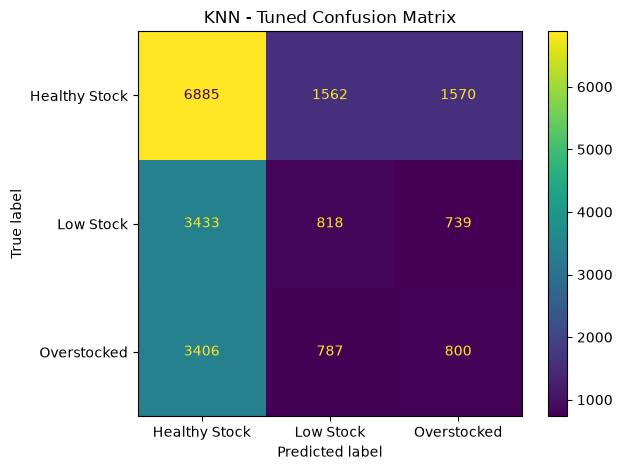

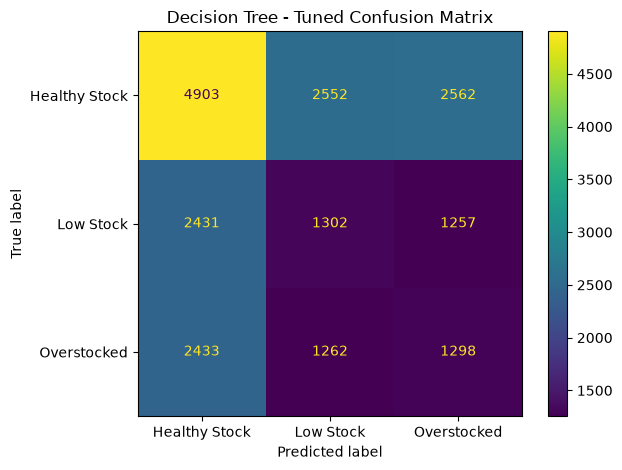

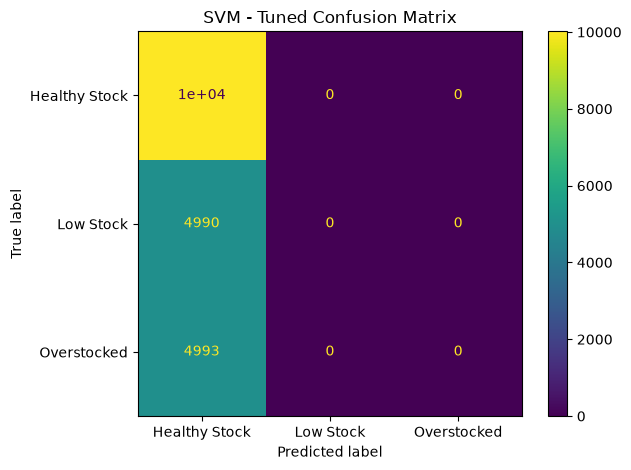

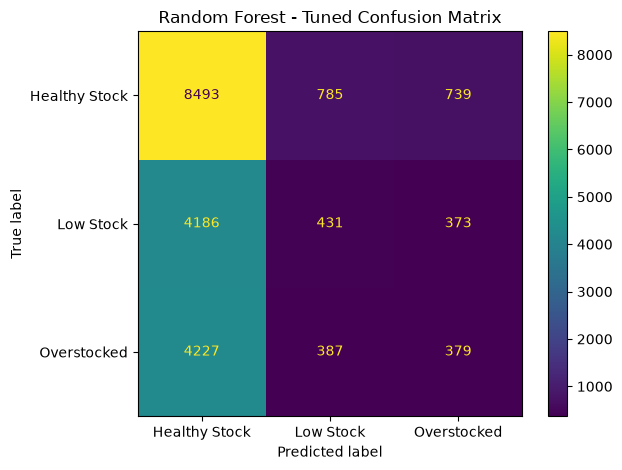

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

tuned_models = {
    "KNN": tuned_knn_predictions,
    "Decision Tree": tuned_dt_predictions,
    "SVM": tuned_svm_predictions,
    "Random Forest": tuned_rf_predictions
}

for model_name, predictions in tuned_models.items():
    cm = confusion_matrix(y_test, predictions)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Healthy Stock", "Low Stock", "Overstocked"]
    )
    
    disp.plot()
    plt.title(f"{model_name} - Tuned Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [22]:
tuned_results_df.to_csv(
    "../outputs/results/tuned_classification_results.csv",
    index=False
)

print("Tuned classification results saved successfully!")

Tuned classification results saved successfully!
